## 1. Scrapping Dataset

In [1]:
import random
import time
import pandas as pd
import requests
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
all_anime_data = []

headers = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
        '(KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
    ),
    'Accept-Language': 'en-US,en;q=0.9',
}

total_pages = 40

print('--- Mulai Scraping MyAnimeList (2.000 Data & 7 Fitur) ---')

for page in range(total_pages):
  limit = page * 50
  url = f'https://myanimelist.net/topanime.php?limit={limit}'

  try:
    response = requests.get(url, headers=headers, timeout=10)

    if response.status_code == 200:
      soup = BeautifulSoup(response.text, 'html.parser')
      rows = soup.select('tr.ranking-list')

      for row in rows:
        row_text = row.get_text(separator=' ', strip=True)

        rank_elem = row.select_one('td.rank span')
        rank = (
            int(rank_elem.text.strip())
            if rank_elem and rank_elem.text.strip().isdigit()
            else None
        )

        title_elem = row.select_one(
            'h3.anime_ranking_h3 a'
        ) or row.select_one('div.detail h3 a')
        title = title_elem.text.strip() if title_elem else None

        score_elem = row.select_one('td.score span')
        try:
          score = (
              float(score_elem.text.strip())
              if score_elem and score_elem.text.strip() != 'N/A'
              else None
          )
        except ValueError:
          score = None

        type_match = re.search(r'\b(TV|Movie|OVA|Special|ONA)\b', row_text)
        anime_type = type_match.group(1) if type_match else 'Unknown'

        eps_match = re.search(r'\((\d+)\s*eps\)', row_text)
        episodes = int(eps_match.group(1)) if eps_match else None

        year_match = re.search(r'\b(19\d\d|20\d\d)\b', row_text)
        start_year = int(year_match.group(1)) if year_match else None

        members_match = re.search(r'([\d,]+)\s*members', row_text)
        members = None
        if members_match:
          members_clean = members_match.group(1).replace(',', '')
          members = int(members_clean)

        if title:
          all_anime_data.append({
              'Rank': rank,
              'Title': title,
              'Type': anime_type,
              'Episodes': episodes,
              'Start_Year': start_year,
              'Score': score,
              'Members': members,
          })

      print(
          f'Halaman {page+1}/{total_pages} selesai | Total data terkumpul:'
          f' {len(all_anime_data)}'
      )

    else:
      print(f'Halaman {page+1} gagal diakses (Status: {response.status_code})')

  except Exception as e:
    print(f'Error pada halaman {page+1}: {e}')

  time.sleep(random.uniform(0.8, 1.5))

print('--- Scraping Selesai ---')

--- Mulai Scraping MyAnimeList (2.000 Data & 7 Fitur) ---
Halaman 1/40 selesai | Total data terkumpul: 50
Halaman 2/40 selesai | Total data terkumpul: 100
Halaman 3/40 selesai | Total data terkumpul: 150
Halaman 4/40 selesai | Total data terkumpul: 200
Halaman 5/40 selesai | Total data terkumpul: 250
Halaman 6/40 selesai | Total data terkumpul: 300
Halaman 7/40 selesai | Total data terkumpul: 350
Halaman 8/40 selesai | Total data terkumpul: 400
Halaman 9/40 selesai | Total data terkumpul: 450
Halaman 10/40 selesai | Total data terkumpul: 500
Halaman 11/40 selesai | Total data terkumpul: 550
Halaman 12/40 selesai | Total data terkumpul: 600
Halaman 13/40 selesai | Total data terkumpul: 650
Halaman 14/40 selesai | Total data terkumpul: 700
Halaman 15/40 selesai | Total data terkumpul: 750
Halaman 16/40 selesai | Total data terkumpul: 800
Halaman 17/40 selesai | Total data terkumpul: 850
Halaman 18/40 selesai | Total data terkumpul: 900
Halaman 19/40 selesai | Total data terkumpul: 950
Ha

In [3]:
df_raw = pd.DataFrame(all_anime_data)
raw_filename = 'data_anime_raw.csv'
df_raw.to_csv(raw_filename, index=False, encoding='utf-8')
print(f"File mentah berhasil disimpan sebagai: '{raw_filename}'")

File mentah berhasil disimpan sebagai: 'data_anime_raw.csv'


## 2. Pemahaman Data

In [4]:
df = pd.read_csv('data_anime_raw.csv')

df.head()

,Rank,Title,Type,Episodes,Start_Year,Score,Members
0,1,Sousou no Frieren,TV,28.0,2023,9.25,1513339
1,2,Fullmetal Alchemist: Brotherhood,TV,64.0,2009,9.11,3733934
2,3,Re:Zero kara Hajimeru Isekai Seikatsu 4th Season,TV,19.0,2026,9.11,327086
3,4,Steel Ball Run: JoJo no Kimyou na Bouken,ONA,NaN,2026,9.08,233069
4,5,Bleach: Sennen Kessen-hen - Kashin-tan,TV,10.0,2026,9.07,162806


In [5]:
print('=== DIMENSI DATASET (.shape) ===')
print(f'Jumlah Baris : {df.shape[0]}')
print(f'Jumlah Kolom : {df.shape[1]}\n')

print('=== TIPE DATA VARIABEL (.dtypes) ===')
print(df.dtypes)
print('\n' + '=' * 40 + '\n')

print('=== INFORMASI LENGKAP DATASET (.info()) ===')
df.info()

=== DIMENSI DATASET (.shape) ===
Jumlah Baris : 2000
Jumlah Kolom : 7

=== TIPE DATA VARIABEL (.dtypes) ===
Rank            int64
Title             str
Type              str
Episodes      float64
Start_Year      int64
Score         float64
Members         int64
dtype: object


=== INFORMASI LENGKAP DATASET (.info()) ===
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Rank        2000 non-null   int64  
 1   Title       2000 non-null   str    
 2   Type        2000 non-null   str    
 3   Episodes    1986 non-null   float64
 4   Start_Year  2000 non-null   int64  
 5   Score       2000 non-null   float64
 6   Members     2000 non-null   int64  
dtypes: float64(2), int64(3), str(2)
memory usage: 109.5 KB


### Identifikasi Tipe Atribut Dataset

Berikut adalah hasil klasifikasi tipe atribut pada dataset hasil *scraping* MyAnimeList:

| Nama Atribut | Tipe Data Pandas | Tipe Atribut Data Mining | Keterangan / Alasan |
| :--- | :--- | :--- | :--- |
| **Rank** | `int64` | **Ordinal** | Menunjukkan tingkatan/urutan posisi ranking anime (1, 2, 3, ...). Memiliki urutan yang bermakna. |
| **Title** | `str` | **Nominal** | Nama/judul anime. Hanya berfungsi sebagai label identitas tanpa adanya tingkatan nilai. |
| **Type** | `str` | **Nominal** | Kategori format tayang (`TV`, `Movie`, `OVA`, `ONA`, `Special`). Tidak ada hierarki antar tipe. |
| **Episodes** | `float64` | **Numerik Diskrit** | Jumlah episode anime berupa kuantitas bilangan bulat positif (misal: 12, 24, 500). |
| **Start_Year** | `int64` | **Numerik Diskrit** | Tahun rilis anime berupa angka bulat. |
| **Score** | `float64` | **Numerik Kontinu** | Rating anime bernilai riil/desimal pada rentang 1.00 – 10.00 (misal: 8.95, 9.10). |
| **Members** | `int64` | **Numerik Diskrit** | Jumlah *user* yang menambahkan anime ke *list*. Berupa kuantitas populasi bilangan bulat. |

## 3. Analisis Statistik dan Kualitas Data

In [6]:
# Menghitung Statistik Deskriptif
numeric_cols = ['Rank', 'Episodes', 'Start_Year', 'Score', 'Members']


desc_stats = pd.DataFrame({
    'Rata-rata (Mean)': df[numeric_cols].mean(),
    'Median': df[numeric_cols].median(),
    'Modus': df[numeric_cols].mode().iloc[0],  
    'Standar Deviasi': df[numeric_cols].std(),
    'Min': df[numeric_cols].min(),
    'Max': df[numeric_cols].max(),
})

print('=== STATISTIK DESKRIPTIF ATRIBUT NUMERIK ===')
desc_stats

=== STATISTIK DESKRIPTIF ATRIBUT NUMERIK ===


,Rata-rata (Mean),Median,Modus,Standar Deviasi,Min,Max
Rank,1000.500000,1000.50,1.00,577.494589,1.00,2000.00
Episodes,17.956193,12.00,1.00,53.051998,1.00,1787.00
Start_Year,2010.912500,2016.00,2023.00,18.270297,1900.00,2026.00
Score,7.958215,7.87,7.58,0.335328,7.55,9.25
Members,323302.695500,124981.00,3243.00,510625.326130,861.00,4424458.00


In [7]:
# Menghitung Frekuensi/Distribusi
print('=== DISTRIBUSI FREKUENSI ATRIBUT KATEGORIKAL (Type) ===')

freq_type = df['Type'].value_counts()
percent_type = (df['Type'].value_counts(normalize=True) * 100).round(2)

kat_summary = pd.DataFrame(
    {'Jumlah (Frekuensi)': freq_type, 'Persentase (%)': percent_type}
)

kat_summary

=== DISTRIBUSI FREKUENSI ATRIBUT KATEGORIKAL (Type) ===


,Jumlah (Frekuensi),Persentase (%)
Type,,
TV,1077,53.85
Movie,463,23.15
ONA,209,10.45
OVA,163,8.15
Special,88,4.40


In [8]:
# Identifikasi Jumlah Missing Values
print('=== IDENTIFIKASI MISSING VALUES ===')

missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame(
    {'Jumlah Missing': missing_count, 'Persentase (%)': missing_percent}
)

missing_df

=== IDENTIFIKASI MISSING VALUES ===


,Jumlah Missing,Persentase (%)
Rank,0,0.0
Title,0,0.0
Type,0,0.0
Episodes,14,0.7
Start_Year,0,0.0
Score,0,0.0
Members,0,0.0


In [9]:
# Deteksi Outliers
print('=== DETEKSI OUTLIER METODE IQR ===')

outlier_list = []

for col in numeric_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

  outlier_list.append({
      'Atribut': col,
      'Q1 (25%)': Q1,
      'Q3 (75%)': Q3,
      'IQR': IQR,
      'Batas Bawah': lower_bound,
      'Batas Atas': upper_bound,
      'Jumlah Outlier': len(outliers),
      'Persentase (%)': round(len(outliers) / len(df) * 100, 2),
  })

outlier_summary_df = pd.DataFrame(outlier_list).set_index('Atribut')
outlier_summary_df

=== DETEKSI OUTLIER METODE IQR ===


,Q1 (25%),Q3 (75%),IQR,Batas Bawah,Batas Atas,Jumlah Outlier,Persentase (%)
Atribut,,,,,,,
Rank,500.75,1500.25,999.50,-998.500,2999.500,0,0.00
Episodes,1.00,19.75,18.75,-27.125,47.875,142,7.10
Start_Year,2008.00,2022.00,14.00,1987.000,2043.000,129,6.45
Score,7.69,8.17,0.48,6.970,8.890,27,1.35
Members,42457.25,358358.50,315901.25,-431394.625,832210.375,221,11.05


## 4. Visualisasi Data

In [10]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

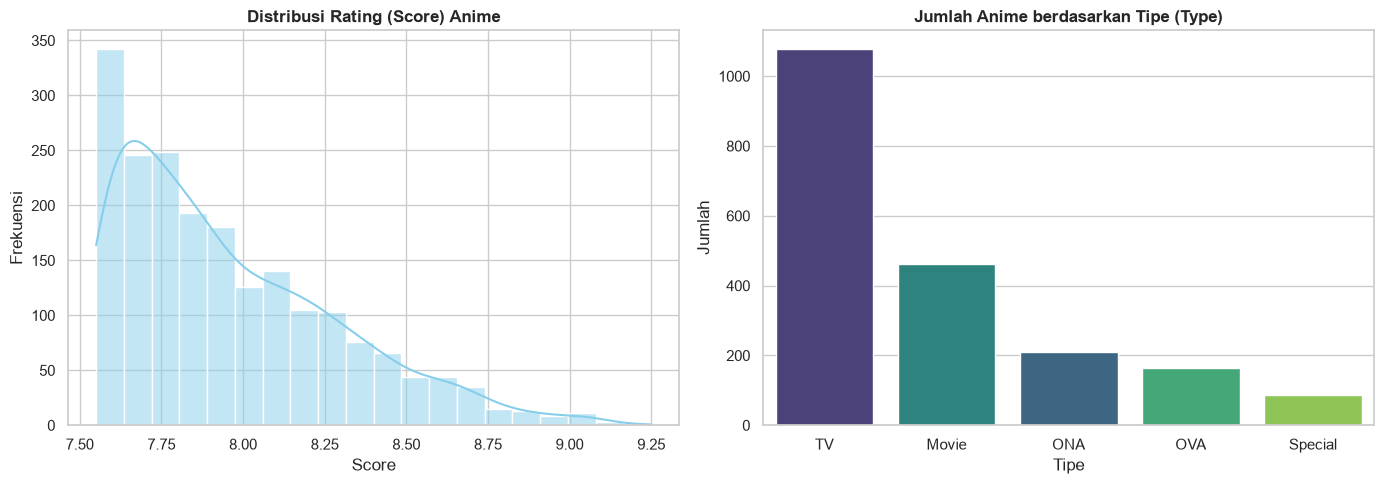

In [11]:
# Visualisasi Univariat
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histogram & KDE: Distribusi Rating/Score
sns.histplot(df['Score'], kde=True, ax=axes[0], color='skyblue', bins=20)
axes[0].set_title(
    'Distribusi Rating (Score) Anime', fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frekuensi')

# 2. Bar Chart: Distribusi Tipe Anime
sns.countplot(
    data=df,
    x='Type',
    hue='Type',
    ax=axes[1],
    palette='viridis',
    order=df['Type'].value_counts().index,
    legend=False,
)
axes[1].set_title(
    'Jumlah Anime berdasarkan Tipe (Type)', fontsize=12, fontweight='bold'
)
axes[1].set_xlabel('Tipe')
axes[1].set_ylabel('Jumlah')

plt.tight_layout()
plt.show()

#### **Interpretasi Visualisasi Univariat:**
1. **Distribusi Score (Histogram):** Grafik menunjukkan distribusi miring ke kanan (*right-skewed*). Sebagian besar anime berkumpul di rentang skor **7.5 – 7.8** (lebih dari 300 anime). Semakin tinggi nilai skornya (>8.5), jumlah animenya semakin sedikit/langka.
2. **Distribusi Type (Bar Chart):** Format serial **TV** sangat mendominasi dataset dengan jumlah lebih dari 1.000 anime, diikuti oleh format **Movie** (~450 anime). Hal ini menunjukkan bahwa serial TV merupakan format utama yang paling banyak disukai dan meraih rating tinggi.

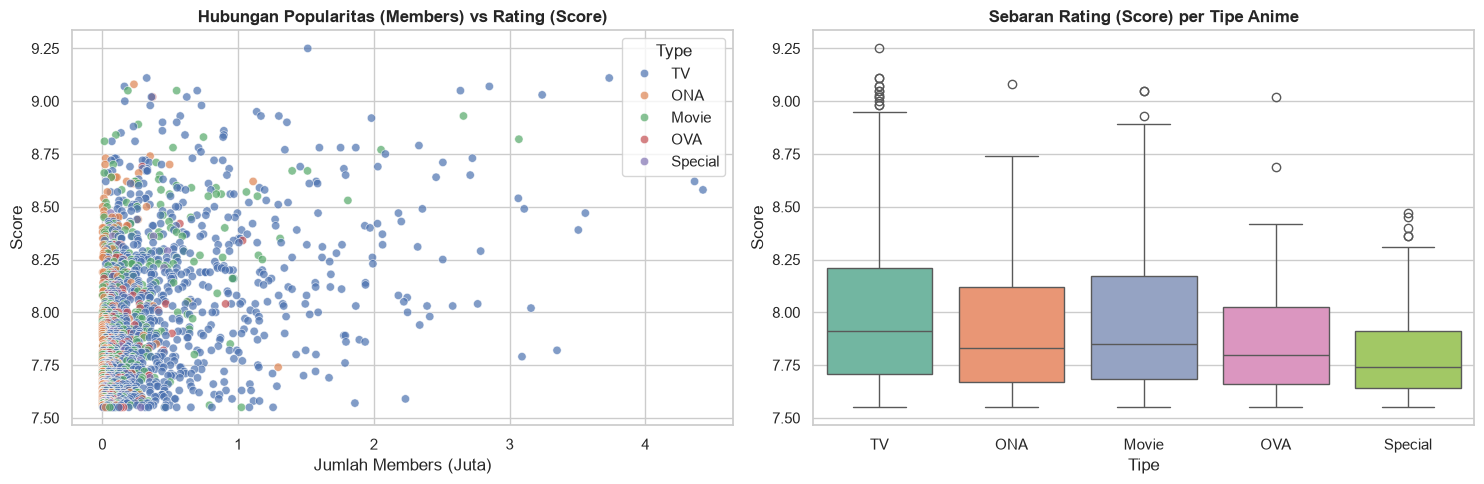

In [12]:
# Visualisasi Bivariat
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Scatter Plot: Members vs Score
sns.scatterplot(
    data=df, x=df['Members']/1_000_000, y='Score', hue='Type', alpha=0.7, ax=axes[0]
)

axes[0].set_title(
    'Hubungan Popularitas (Members) vs Rating (Score)',
    fontsize=12,
    fontweight='bold',
)

axes[0].set_xlabel('Jumlah Members (Juta)')
axes[0].set_ylabel('Score')

# 2. Boxplot: Score berdasarkan Type
sns.boxplot(
    data=df,
    x='Type',
    y='Score',
    hue='Type',
    palette='Set2',
    ax=axes[1],
    legend=False,
)

axes[1].set_title(
    'Sebaran Rating (Score) per Tipe Anime', fontsize=12, fontweight='bold'
)

axes[1].set_xlabel('Tipe')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

#### **Interpretasi Visualisasi Bivariat:**
1. **Scatter Plot (Members vs Score):** Terdapat tren positif — anime dengan popularitas sangat tinggi (di atas 1–2 juta *members*) hampir seluruhnya mengumpul di area skor tinggi (>8.0). Namun, pada area *members* yang relatif rendah (<500 ribu), variasi skornya sangat luas, bahkan ada beberapa anime *niche*/klasik yang menembus skor sangat tinggi (>8.8).
2. **Boxplot (Score per Type):** Format **TV** dan **Movie** memiliki nilai median skor tertinggi (~7.9). Titik-titik *outlier* pada seluruh tipe anime berada di **batas atas** (skor 8.5 – 9.25), di mana format **TV** memiliki titik outlier skor tinggi paling banyak

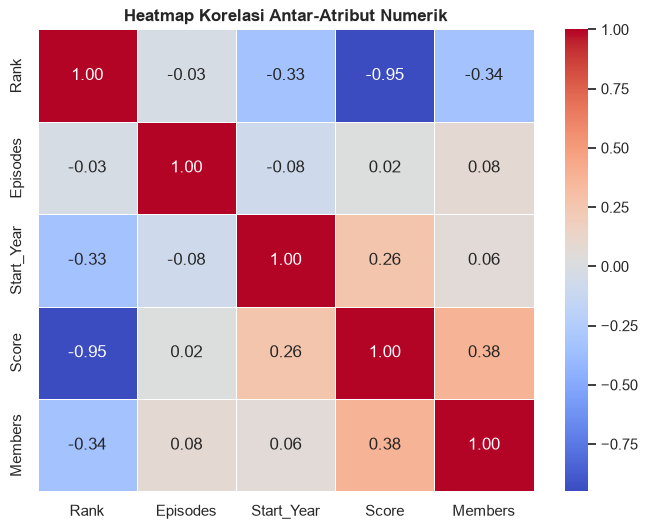

In [13]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))

corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar-Atribut Numerik', fontsize=12, fontweight='bold')
plt.show()

#### **Interpretasi Correlation Heatmap:**
1. **Rank vs Score (-0.95):** Memiliki korelasi negatif yang sangat kuat (mendekati -1.00). Hal ini sangat logis karena semakin kecil nilai `Rank` (posisi urutan atas seperti peringkat 1, 2, 3), semakin tinggi nilai `Score`-nya.
2. **Members vs Score (0.38):** Memiliki korelasi positif lemah hingga sedang. Jumlah *members* (popularitas) cenderung berbanding lurus dengan nilai *Score*, meskipun popularitas bukan satu-satunya penentu rating tinggi.
3. **Rank vs Members (-0.34):** Memiliki korelasi negatif sedang. Anime yang menempati peringkat atas (`Rank` kecil) secara umum menarik lebih banyak *members* di platform.
4. **Start_Year vs Score (0.27):** Memiliki korelasi positif lemah, mengindikasikan anime rilisan tahun-tahun yang lebih baru cenderung mendapatkan penilaian skor sedikit lebih tinggi.